<a href="https://colab.research.google.com/github/gerbaudo/oak-car-counter/blob/main/ocr_camspeed_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OCR on camera speed radar

The goal of this notebook is to extract some simple statitics about traffic on the road in front of our house. The data were collected over a couple of days (Feb 2020) with the application [SpeedRadarCam](https://play.google.com/store/apps/details?id=androix.com.android.SpeedRadarCam&hl=en) running on an old Android phone. The app is configured with two reference points that are about $8\pm0.5$m apart. Each time an object moves across the two reference points, the app provides a picture. In order to get some statistics, I want to access the timestamp and the speed. The timestamp is decoded from the filename. The speed is currently written on the picture, so I need to extract the text from the images recorder by "Speed Radar Cam".


DG
2020-02-16

In [ ]:
!sudo apt install tesseract-ocr --quiet
!pip install --upgrade --quiet pytesseract gspread

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 29 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 3s (1,764 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Di

In [ ]:
import sys
!{sys.executable} -m pip install -U pandas-profiling
!jupyter nbextension enable --py widgetsnbextension

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.6/262.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.8/309.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.4 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=6610642a26f69c7fde0a3e833988d0cdb1ec808fc77e4a121fd37e55c8c6683c
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.

In [ ]:
import pytesseract
import shutil
import os
import numpy as np
import pandas as pd
import csv
import random
try:
  from PIL import Image
except ImportError:
  import Image
import cv2
from google.colab.patches import cv2_imshow
from IPython import display
from google.colab import drive

### Working
Picked the configuration (preprocessing) that seems to work best.
Test it on 4 images: the speed is detected correctly in all of them.

Next thing to do: upload all images to a Google Photo album, and scan all of them. Then produce a Pandas dataframe.

In [ ]:
def speed_from_image(img_name, verbose=False):
  img = cv2.imread(img_name)
  x, y, w, h = 0, 480, 100, 12
  crop_bot = img[y-h:y, x:x+w]
  img_scaleup = cv2.resize(crop_bot, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
  img_bf = cv2.bilateralFilter(img_scaleup,9,75,75)
  # text = pytesseract.image_to_string(img_bf)
  # two additional pre-processing steps: convert to greyscale and invert white-black to black-white
  img_bw = cv2.subtract(255,cv2.cvtColor(img_bf, cv2.COLOR_BGR2GRAY))
  text = pytesseract.image_to_string(img_bw)
  if verbose:
    print(f"from {img_name} parsed '{text}'")
  tokens = text.split()
  # expect to parse something like 'yel: 54.0 kin¢h'
  return tokens[1] if len(tokens)>1 else None

In [ ]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
#
base_path='/content/drive/My Drive/Speedcamradar2/SpeedRadarCam'
subdirs = [x[0] for x in os.walk(base_path) if '20' in x[0]] # get all subdirs, whose name is 20YYMMDD
subdirs.sort()
subdirs

['/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190901',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190902',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190905',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200222',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200223',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200301',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200302',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200303',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200304',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200305',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200306',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200307',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200308',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200417',
 '/content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200418',
 '/content

In [ ]:
csv_filename='files_with_speed.csv'
def get_cache_from_csv(dir_path, filename=csv_filename, verbose=False):
  full_path = os.path.join(dir_path, filename)
  is_there = os.path.exists(full_path)
  if verbose:
    print("%s %s" % (('Reading' if is_there else 'Missing'), full_path))
  return pd.read_csv(full_path) if is_there else pd.DataFrame(columns=['filename', 'speed'])
def update_cache_to_csv(dir_path, filename=csv_filename, verbose=False):
  df_cache = get_cache_from_csv(dir_path, verbose=verbose)
  filenames_cached = df_cache.filename.values.tolist()
  filenames = [f for f in os.listdir(dir_path)
    if f.endswith('.jpg')
    and (f.startswith('2019') or f.startswith('2020'))
    and '(1)' not in f # skip duplicates
    and f not in filenames_cached] # skip what is already there
  speeds = [speed_from_image(dir_path+'/'+fn, verbose=verbose) for fn in filenames]
  # the '5' is sometimes confused with a '$'
  speeds = [s.replace('$','5') for s in speeds if s] # also skip what didn't parse anything
  files_with_speed = {f:s for f,s in zip(filenames + df_cache.filename.values.tolist(), # append existing values
                                         speeds + df_cache.speed.values.tolist())}
  df_out = pd.DataFrame([(k,v) for k,v in files_with_speed.items()],
                        columns=['filename', 'speed'])
  csv_full_path = os.path.join(dir_path, filename)
  has_new_rows = df_out.shape[0] > df_cache.shape[0]
  # cache to disk for the next time
  # note to self: you can also go in google docs and manually fix the few values that are still incorrectly OCR'ed
  if has_new_rows:
    print(f"chaching output {df_cache.shape} replacing {df_out.shape}")
    if os.path.exists(csv_full_path):
      os.remove(csv_full_path)
    df_out.to_csv(csv_full_path, index=False)
  return df_out

dfs_all_days = [update_cache_to_csv(dir_path=subdir, verbose=True)
  for subdir in subdirs]

Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190901/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190902/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20190905/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200222/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200223/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200301/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200302/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200303/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200304/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200305/files_with_speed.csv
Reading /content/drive/My Drive/Speedcamradar2/SpeedRadarCam/20200306/files_with_speed.csv

In [ ]:
df = pd.concat(dfs_all_days)
df.describe()

,filename,speed
count,13643,13643
unique,13643,2939
top,20190901_193705.jpg,42.54
freq,1,56


In [ ]:
df['timestamp'] = pd.to_datetime(df.filename, format='%Y%m%d_%H%M%S.jpg')

In [ ]:
df = df.set_index('timestamp').drop(columns=['filename'])

In [ ]:
df['speed'] = pd.to_numeric(df.speed, errors='coerce')

In [ ]:
# check the outliers
df[df.speed>100.]

,speed
timestamp,
2019-09-02 08:21:05,171.09
2020-03-03 07:28:36,106.67
2020-03-03 20:34:52,147.69
2020-03-04 09:49:43,106.27
2020-04-17 16:17:07,106.27
...,...
2020-08-28 11:54:06,112.94
2020-08-28 13:42:35,104.35
2020-08-29 08:07:18,490.01


In [ ]:
print(f"outliers {df[df.speed>100.].shape} out of {df.shape}")

outliers (295, 1) out of (13643, 1)


In [ ]:
# the values above are mistakes in the OCR (20.51 and 11.09)
# ... drop them
# Alternatively fix them manually in the cached csv.
df2 = df[~(df['speed'] > 100.0)]

<Axes: xlabel='timestamp'>

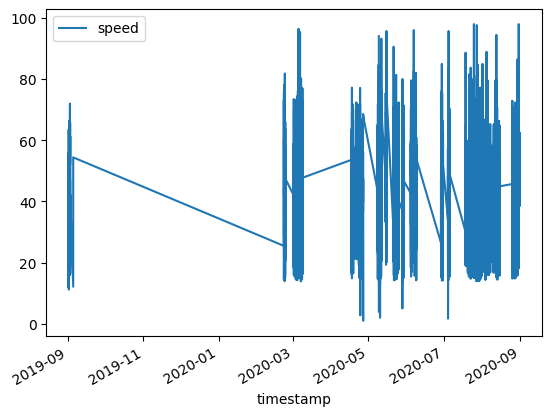

In [ ]:
df2.plot()

In [ ]:
from pandas_profiling import ProfileReport
profile = ProfileReport(df2, title='Pandas Profiling Report')
profile

Summarize dataset:   0%|          | 0/15 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

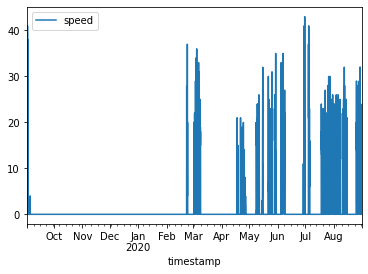

In [ ]:
hourly = df2.resample('H').count()
hourly.plot()

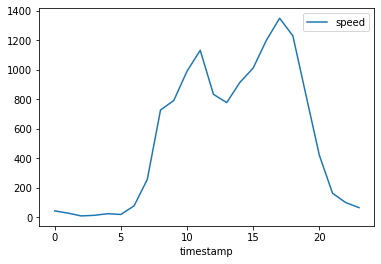

In [ ]:
# How many counts every hour? (independently of the day)
by_time = df2.groupby(df2.index.hour).count()
by_time.plot()
#  see more examples at
# https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html
# hourly_ticks = 4 * 60 * 60 * np.arange(6)
# by_time.plot(xticks=hourly_ticks)

Fit results: mu = 42.50,  std = 10.95


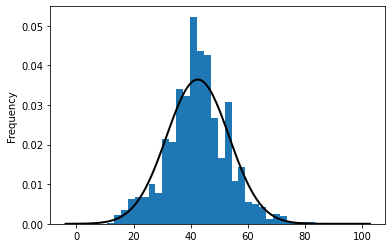

In [ ]:
# just a histogram of the speeds
# The speed limit is 30 km/h; the median is about 40 km/h, with some crazy people driving at 80 km/h.
# From manual inspection it looks like most of the fast cars are entering the 30 km/h zone.
# Vehicles exiting the zone seem to be a bit slower on average; to confirm this I would need to find a way to detect the direction of motion.
# The app computes the abs speed...
with pd.option_context('mode.use_inf_as_null', True):
   df3 = df2.dropna()
from scipy.stats import norm
import numpy as np
# Fit a normal distribution to the data:
mu, std = norm.fit(df3.speed)
ax = df3.speed.plot.hist(bins=40, density=True)
xmin, xmax, ymin, ymax = ax.axis()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
print("Fit results: mu = %.2f,  std = %.2f" % (mu, std))

In [ ]:
df2.speed.describe()

count    13000.000000
mean        42.503632
std         10.949204
min          1.008800
25%         35.870000
50%         42.350000
75%         48.730000
max         97.960000
Name: speed, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

N: [   6.  268. 1065. 3519. 5167. 2340.  426.  164.   29.   16.]
bins: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]
patches: <a list of 10 Patch objects>


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:24: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


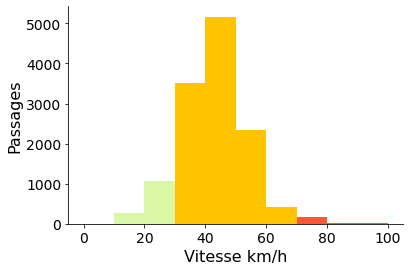

In [ ]:
N, bins, patches = plt.hist(df2['speed'], bins=10, range=(0,100))

print(f"N: {N}")
print(f"bins: {bins}")
print(f"patches: {patches}")

cmap = plt.get_cmap('jet')
low = cmap(0.5)
medium =cmap(0.2)
high = cmap(0.7)


for i in range(0,3):
    patches[i].set_facecolor('#daf7a6')
for i in range(3,7):
    patches[i].set_facecolor('#ffc300')
for i in range(7,10):
    patches[i].set_facecolor('#ff5733')

plt.xlabel("Vitesse km/h", fontsize=16)
plt.ylabel("Passages", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = plt.subplot(111)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

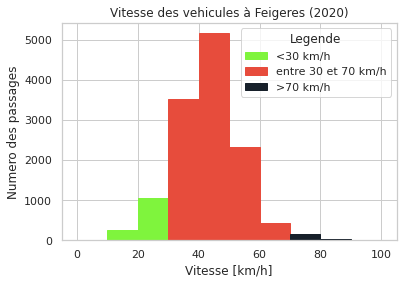

In [ ]:
import matplotlib.pyplot as plt
import numpy             as np
import seaborn as sns
sns.set(color_codes=True)
sns.set_style('whitegrid')

number_of_bins = 10
N, bins, patches = plt.hist(df2['speed'], bins=10, range=(0,100))

#Define the colors for the pathces (green, yellow red)
colors = ['#7ff43d', '#f39c12', '#e74c3c']
colors = ['#7ff43d', '#e74c3c', '#17202a']

#Define the ranges of your patches:
divisions = [range(3), range(3, 7), range(7, 10)]
#label the regions
labels    = ["<30 km/h", "entre 30 et 70 km/h", ">70 km/h"]

for d in divisions:
    patches[list(d)[0]].set_label(labels[divisions.index(d)])
    for i in d:
        patches[i].set_color(colors[divisions.index(d)])


plt.title("Vitesse des vehicules à Feigeres (2020)")
plt.xlabel("Vitesse [km/h]")
plt.ylabel("Numero des passages")
plt.legend(title="Legende")

In [ ]:
# percentages in each range
ranges = [0,30,70,100]
#df_counts = df2.groupby(pd.cut(df2.speed, ranges)).agg({'speed':{'counts':'count'}})
df_counts = df2.groupby(pd.cut(df2.speed, ranges)).agg({'speed':'count'})
df_counts

,speed
speed,
"(0, 30]",1352
"(30, 70]",11439
"(70, 100]",209


In [ ]:
counts = df_counts.speed.values
total = sum(counts)
below_30 = counts[0]
between_30_70 = counts[1]
above_70 = counts[2]

print(f"{(below_30/total):.0%} below 30")
print(f"{((between_30_70+above_70)/total):.0%} between 30 and 70")
print(f"{(above_70/total):.0%} above 70")


10% below 30
90% between 30 and 70
2% above 70


In [ ]:
total

13000

In [ ]:
!pip install pymc3
import pymc3 as pm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of pymc3 to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.8 MB/s eta 0:00:00
  Created wheel for theano-pymc: filename=Theano_PyMC-1.1.2-py3-none-any.whl size=1529959 sha256=2e2b816dd9240423c38f183182b83b18275955124e042c786793e5b79400edc6
  Stored in directory: /root/.cache/pip/wheels/fb/d3/25/6c443075ee21f3b6a59a6a180b55657b012722e1b89f8ccbe8
Successfully built theano-pymc


/usr/local/lib/python3.11/dist-packages/theano/scalar/basic.py:2412: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  self.ctor = getattr(np, o_type.dtype)


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:
!pip install pymc3==3.11.5
import pymc3 as pm

  Using cached pymc3-3.11.5-py3-none-any.whl.metadata (14 kB)
  Using cached deprecat-2.1.3-py2.py3-none-any.whl.metadata (1.6 kB)
  Using cached numpy-1.22.1.zip (11.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of pymc3 to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Py

AttributeError: partially initialized module 'theano' has no attribute 'compile' (most likely due to a circular import)

In [ ]:
!pip install --upgrade --quiet theano pymc3==3.11.5
import pymc3 as pm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3

AttributeError: partially initialized module 'theano' has no attribute 'compile' (most likely due to a circular import)

In [ ]:
!pip install --upgrade --quiet theano pymc3==3.11.5 --force-reinstall
import pymc3 as pm

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.1 MB/s eta 0:00:00
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=

AttributeError: partially initialized module 'theano' has no attribute 'compile' (most likely due to a circular import)

In [ ]:
!pip install --upgrade --quiet theano
!pip install pymc3==3.11.5

  Preparing metadata (setup.py) ... done
  Using cached pymc3-3.11.5-py3-none-any.whl.metadata (14 kB)
  Using cached deprecat-2.1.3-py2.py3-none-any.whl.metadata (1.6 kB)
  Using cached numpy-1.22.1.zip (11.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of pymc3 to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requi

In [ ]:
df3.head

<bound method NDFrame.head of                      speed
timestamp                 
2019-09-01 19:37:05  50.23
2019-09-01 19:03:24  55.10
2019-09-01 18:59:09  14.45
2019-09-01 19:07:28  46.35
2019-09-01 19:46:33  20.35
...                    ...
2020-08-31 08:17:20  62.61
2020-08-31 08:10:51  56.80
2020-08-31 08:10:41  45.43
2020-08-31 08:20:06  44.38
2020-08-31 08:26:26  38.61

[13000 rows x 1 columns]>

In [ ]:
dates = df3.index
speeds = df3.speed
dates.min(), dates.max()
print(pm.__version__)

3.7


In [ ]:
df4 = df3 # df3.reset_index()
df4.head()

with pm.Model() as speed_model_0:
  speed_test = pm.Data("speeds", df3["speed"],
                           #dims="timestamp",
                           #export_index_as_coords=True
                           )


In [ ]:
dates = df3.index
speeds = df3.speed


# TODO
# convert the dates index to a continous index (i.e. remove the gaps, we only care about before/after)
# model the speed as a gaussian distribution with a parameter gaussia mean and gaussian sigma

with pm.Model() as speed_model:

    switchpoint = pm.DiscreteUniform(
        "switchpoint", lower=dates.min(), upper=dates.max(), testval=pd.Timestamp('2020-03-01')
    )

    # Priors for pre- and post-switch rates number of disasters
    early_speed = pm.Normal('early_speed', mu=42, sigma=10)
    late_speed = pm.Normal('late_speed', mu=42, sigma=10)

    # Allocate appropriate Poisson rates to years before and after current
    speed = pm.math.switch(switchpoint >= dates, early_speed, late_speed)

    speeds_m = pm.Normal("speeds_m", speed, observed=speeds)

NameError: name 'df3' is not defined

In [ ]:
df2

,speed
timestamp,
2019-09-01 19:37:05,50.23
2019-09-01 19:03:24,55.10
2019-09-01 18:59:09,14.45
2019-09-01 19:07:28,46.35
2019-09-01 19:46:33,20.35
...,...
2020-08-31 08:17:20,62.61
2020-08-31 08:10:51,56.80
2020-08-31 08:10:41,45.43


from matplotlib import pyplot as plt
df2['speed'].plot(kind='hist', bins=20, title='speed')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df2['speed'].plot(kind='line', figsize=(8, 4), title='speed')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# prompt: Using dataframe df2: save to a csv file

# Save the DataFrame to a CSV file named 'df2.csv'
df2.to_csv('df2.csv', index=False) # index=False prevents writing row indices to the file
